<a href="https://colab.research.google.com/github/maitevoitmanm/miprimergithub/blob/main/examenccdd_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Uso de la API del Banco Mundial
La API del Banco Mundial proporciona acceso inmediato a información económica, social y poblacional de diversos países. Su empleo posibilita la obtención automatizada de datos oficiales y confiables, favoreciendo el análisis comparado y la replicabilidad de las investigaciones en ciencia de datos.


## Etapa 1

In [4]:
#Primero instalamos la biblioteca
%pip install wbgapi

Primero instalamos la librería wbgapi, la que deja entrar de forma directa a la información libre del Banco Mundial usando Python.

In [5]:
import wbgapi as wb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

Estas bibliotecas se usan para manipular datos, poder graficar y conectar con el banco mundial

In [6]:
from google.colab import drive
from datetime import datetime
drive.mount('/content/drive')

import sys
sys.path.append('/content/drive/MyDrive/CDE/')

import my_func as fn



Mounted at /content/drive


Se utiliza Google Drive para almacenar y cargar archivos, en particular funciones auxiliares previamente desarrolladas por el profesor o el estudiante (my_func.py). Posteriormente, se incorpora la ruta del archivo de funciones y se importa como fn, lo que permite emplear funciones personalizadas, como la descarga de datos por bloques

In [7]:
# Indicadores a consultar
indicadores_wb = {
    "NY.GDP.MKTP.PP.KD": "GDP, PPP (constant 2021 international $)",
    "SP.POP.GROW": "Population growth (annual %)",
    "SP.POP.TOTL": "Population, total",
    "SP.POP.TOTL.FE.IN": "Population, female",
    "SP.POP.TOTL.FE.ZS": "Population, female (% of total population)",
    "SP.POP.TOTL.MA.IN": "Population, male",
    "SP.POP.TOTL.MA.ZS": "Population, male (% of total population)",
    "SP.URB.GROW": "Urban population growth (annual %)",
    "SP.URB.TOTL": "Urban population",
    "SP.URB.TOTL.IN.ZS": "Urban population (% of total population)",
    "SP.RUR.TOTL": "Rural population",
    "SP.RUR.TOTL.ZG": "Rural population growth (annual %)",
    "SP.RUR.TOTL.ZS": "Rural population (% of total population)",
    "SL.TLF.TOTL.IN": "Labor force, total",
    "SL.TLF.TOTL.FE.ZS": "Labor force, female (% of total labor force)",
    "SL.UEM.TOTL.FE.NE.ZS": "Unemployment, female (% of female labor force) (national estimate)",
    "SL.UEM.TOTL.FE.ZS": "Unemployment, female (% of female labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.MA.NE.ZS": "Unemployment, male (% of male labor force) (national estimate)",
    "SL.UEM.TOTL.MA.ZS": "Unemployment, male (% of male labor force) (modeled ILO estimate)",
    "SL.UEM.TOTL.NE.ZS": "Unemployment, total (% of total labor force) (national estimate)",
    "SL.UEM.TOTL.ZS": "Unemployment, total (% of total labor force) (modeled ILO estimate)",
    "FP.CPI.TOTL.ZG": "Inflation, consumer prices (annual %)",
    "GC.TAX.EXPT.CN": "Taxes on exports (current LCU)",
    "GC.TAX.EXPT.ZS": "Taxes on exports (% of tax revenue)",
    "NE.EXP.GNFS.KD.ZG": "Exports of goods and services (annual % growth)",
    "NE.EXP.GNFS.KN": "Exports of goods and services (constant LCU)",
    "NE.EXP.GNFS.ZS": "Exports of goods and services (% of GDP)",
    "NV.AGR.TOTL.CD": "Agriculture, forestry, and fishing, value added (current US$)",
    "NV.AGR.TOTL.CN": "Agriculture, forestry, and fishing, value added (current LCU)",
    "NV.IND.MANF.CD": "Manufacturing, value added (current US$)",
    "NV.IND.MANF.CN": "Manufacturing, value added (current LCU)",
    "NV.IND.TOTL.CD": "Industry (including construction), value added (current US$)",
    "NV.IND.TOTL.CN": "Industry (including construction), value added (current LCU)",
    "NV.SRV.TOTL.CD": "Services, value added (current US$)",
    "NV.SRV.TOTL.CN": "Services, value added (current LCU)",
    "GE.EST": "Government Effectiveness: Estimate",
    "NE.CON.GOVT.KN": "General government final consumption expenditure (constant LCU)",
    "NE.CON.GOVT.ZS": "General government final consumption expenditure (% of GDP)",
    "NE.CON.PRVT.CD": "Households and NPISHs Final consumption expenditure (current US$)",
    "NE.CON.PRVT.CN": "Households and NPISHs Final consumption expenditure (current LCU)",
    "GC.DOD.TOTL.CN": "Central government debt, total (current LCU)",
    "GC.DOD.TOTL.GD.ZS": "Central government debt, total (% of GDP)",
    "BM.KLT.DINV.CD.WD": "Foreign direct investment, net outflows (BoP, current US$)",
    "BX.KLT.DINV.WD.GD.ZS": "Foreign direct investment, net inflows (% of GDP)",
    "EG.ELC.LOSS.ZS": "Electric power transmission and distribution losses (% of output)",
    "EG.USE.ELEC.KH.PC": "Electric power consumption (kWh per capita)",
    "EN.GHG.CO2.IP.MT.CE.AR5": "Carbon dioxide emissions from Industrial Processes (Mt CO2e)",
    "SE.PRM.NENR": "School enrollment, primary (% net)",
    "SE.PRM.NENR.FE": "School enrollment, primary, female (% net)",
    "SE.PRM.NENR.MA": "School enrollment, primary, male (% net)",
    "SE.SEC.ENRR": "School enrollment, secondary (% gross)",
    "SE.SEC.ENRR.FE": "School enrollment, secondary, female (% gross)",
    "SE.SEC.ENRR.MA": "School enrollment, secondary, male (% gross)",
    "SE.TER.ENRR": "School enrollment, tertiary (% gross)",
    "SE.TER.ENRR.FE": "School enrollment, tertiary, female (% gross)",
    "SE.TER.ENRR.MA": "School enrollment, tertiary, male (% gross)",
    "SP.DYN.LE00.IN": "Life expectancy at birth, total (years)",
    "SP.DYN.LE00.FE.IN": "Life expectancy at birth, female (years)",
    "SP.DYN.LE00.MA.IN": "Life expectancy at birth, male (years)",
    "EG.CFT.ACCS.ZS": "Access to clean fuels and technologies for cooking (% of population)",
    "EG.CFT.ACCS.RU.ZS": "Access to clean fuels and technologies for cooking, rural (% of rural population)",
    "EG.CFT.ACCS.UR.ZS": "Access to clean fuels and technologies for cooking, urban (% of urban population)",
    "IT.NET.USER.FE.ZS": "Individuals using the Internet, female (% of female population)",
    "IT.NET.USER.MA.ZS": "Individuals using the Internet, male (% of male population)",
    "IT.NET.USER.ZS": "Individuals using the Internet (% of population)",
}

Se establece un diccionario que contiene los indicadores de interés a consultar, lo que permite estructurar y personalizar la obtención de datos pertinentes para el análisis socioeconómico.

In [8]:
paises_wb_raw = fn.descargar_en_chunks(indicadores=indicadores_wb,años=2023, chunk_size = 15)

Descargando bloque 1: ['NY.GDP.MKTP.PP.KD', 'SP.POP.GROW', 'SP.POP.TOTL', 'SP.POP.TOTL.FE.IN', 'SP.POP.TOTL.FE.ZS', 'SP.POP.TOTL.MA.IN', 'SP.POP.TOTL.MA.ZS', 'SP.URB.GROW', 'SP.URB.TOTL', 'SP.URB.TOTL.IN.ZS', 'SP.RUR.TOTL', 'SP.RUR.TOTL.ZG', 'SP.RUR.TOTL.ZS', 'SL.TLF.TOTL.IN', 'SL.TLF.TOTL.FE.ZS']
Descargando bloque 2: ['SL.UEM.TOTL.FE.NE.ZS', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.NE.ZS', 'SL.UEM.TOTL.MA.ZS', 'SL.UEM.TOTL.NE.ZS', 'SL.UEM.TOTL.ZS', 'FP.CPI.TOTL.ZG', 'GC.TAX.EXPT.CN', 'GC.TAX.EXPT.ZS', 'NE.EXP.GNFS.KD.ZG', 'NE.EXP.GNFS.KN', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN', 'NV.IND.MANF.CD']
Descargando bloque 3: ['NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD', 'NV.SRV.TOTL.CN', 'GE.EST', 'NE.CON.GOVT.KN', 'NE.CON.GOVT.ZS', 'NE.CON.PRVT.CD', 'NE.CON.PRVT.CN', 'GC.DOD.TOTL.CN', 'GC.DOD.TOTL.GD.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'EG.ELC.LOSS.ZS']
Descargando bloque 4: ['EG.USE.ELEC.KH.PC', 'EN.GHG.CO2.IP.MT.CE.AR5', 'SE.PRM.NENR', '

Se emplea una función personalizada para descargar los indicadores seleccionados en bloques, con el fin de evitar errores asociados a un exceso de columnas. Además, se utiliza el año 2023 para contar con información actualizada.
> Añadir blockquote



Análisis datos

In [9]:
paises_wb_raw.tail(5)

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
261,CEB,Central Europe and the Baltics,4.218704e+12,45.670155,49100893.0,0.111693,100183707.0,51639515.0,51.544825,48544192.0,...,80.939987,56.712559,81.624607,77.896625,74.354109,100.000000,100.000000,NaN,NaN,NaN
262,CSS,Caribbean small states,1.338577e+11,43.965332,1919128.0,0.501131,4519904.0,2293907.0,50.751230,2225997.0,...,NaN,NaN,76.456921,73.171645,69.986624,95.267180,98.879872,NaN,NaN,NaN
263,ARB,Arab World,8.097600e+12,19.141318,132483437.0,2.255866,482105978.0,232702770.0,48.267971,249403208.0,...,34.757931,31.807100,74.418910,72.444678,70.619437,77.839625,93.857501,NaN,NaN,NaN
264,AFW,Africa Western and Central,2.992692e+12,46.355771,212022202.0,2.386204,509398589.0,252899429.0,49.646669,256499160.0,...,NaN,NaN,59.997102,58.855722,57.752356,6.004144,45.206379,33.0,44.0,38.5
265,AFE,Africa Eastern and Southern,3.065002e+12,47.278292,288476515.0,2.519167,750491370.0,379019549.0,50.502852,371471821.0,...,NaN,NaN,67.914632,65.146154,62.395419,10.288154,41.289974,24.8,30.9,27.8


In [10]:
#Seleccionar países usando ISO
table_dict = vars(wb.economy.info())
df_paises = pd.DataFrame(table_dict.get('items'))
iso_list = list(df_paises[df_paises['aggregate']==False]['id'])

In [11]:
#Seleccionamos solo países
paises_wb_raw = paises_wb_raw[paises_wb_raw['country'].isin(iso_list)].reset_index(drop = True)

Los datos descargados incluyen países y sus agregados, las regiones y los continentes. Aquí se filtran únicamente los países reales usando su código ISO para tener un análisis más representativo.

Ahora solo con los países hacemos el análisis exploratorio de los datos

In [12]:
paises_wb_raw.tail()

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
193,AGO,Angola,3.229678e+11,49.450638,15430003.0,3.080655,36749906.0,18568216.0,50.525887,18181690.0,...,9.933616,10.165600,67.144,64.617,62.099,8.4,75.0,NaN,NaN,44.7581
194,AND,Andorra,5.225828e+09,NaN,NaN,1.433748,80856.0,39502.0,48.854754,41354.0,...,68.003820,57.193764,86.107,84.041,82.100,100.0,100.0,NaN,NaN,95.4456
195,DZA,Algeria,6.998184e+11,16.830056,13174228.0,1.498976,46164219.0,22614984.0,48.988123,23549235.0,...,67.258843,44.258295,77.696,76.261,74.895,99.1,99.9,NaN,NaN,76.9081
196,ALB,Albania,4.944312e+10,44.994435,1210263.0,-1.543108,2414095.0,1220548.0,50.559226,1193547.0,...,77.031527,52.749937,81.446,79.602,77.728,72.5,95.2,81.7239,84.59,83.1356
197,AFG,Afghanistan,8.223848e+10,6.846247,8866507.0,2.135594,41454761.0,20530683.0,49.525513,20924078.0,...,NaN,NaN,67.536,66.035,64.467,20.4,87.0,NaN,NaN,17.7089


Análisis descriptivos

In [13]:
paises_wb_raw.describe()

,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,SP.POP.TOTL.MA.ZS,SP.RUR.TOTL,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
count,1.980000e+02,173.000000,1.730000e+02,198.000000,1.980000e+02,1.980000e+02,198.000000,1.980000e+02,198.000000,1.980000e+02,...,122.000000,122.000000,198.000000,198.000000,198.000000,182.000000,182.000000,57.000000,57.000000,177.000000
mean,8.388712e+11,41.898361,2.076029e+07,1.152752,3.999611e+07,1.987776e+07,49.973491,2.011836e+07,50.026509,1.709937e+07,...,60.958578,45.456089,76.119303,73.476060,70.910354,62.271154,78.501099,87.190260,88.240505,72.290555
std,3.129922e+12,9.018596,7.637237e+07,1.576210,1.484957e+08,7.252840e+07,2.993389,7.598056e+07,2.993389,7.663858e+07,...,35.784689,28.107669,7.221813,7.085527,7.104323,41.324522,32.394985,13.774667,12.542169,24.224349
min,5.705451e+07,6.846247,3.361400e+04,-8.423008,9.816000e+03,4.795000e+03,28.483741,5.021000e+03,45.079120,0.000000e+00,...,4.663074,2.806122,54.743000,54.462000,53.195000,0.000000,0.100000,16.697100,19.497300,11.078400
25%,2.586691e+10,40.069279,1.210263e+06,0.282878,1.373786e+06,6.876850e+05,49.651875,6.826450e+05,48.810555,4.134135e+05,...,30.014082,20.436952,70.733000,67.713000,65.379000,11.062500,69.650000,84.786500,86.108800,58.278900
50%,8.596764e+10,45.081945,4.220673e+06,1.112108,7.335048e+06,3.672054e+06,50.329281,3.560820e+06,49.670719,1.983892e+06,...,63.036400,44.203554,77.486500,74.292890,70.666000,84.150000,97.600000,89.829000,90.538300,81.722100
75%,4.615291e+11,47.539585,1.317423e+07,2.088224,2.936413e+07,1.403224e+07,51.189445,1.424457e+07,50.348125,1.024225e+07,...,89.311148,63.348878,81.700000,78.485976,75.803000,100.000000,100.000000,94.406300,95.100000,89.896000
max,3.200488e+13,54.670843,7.746076e+08,6.527050,1.438070e+09,6.961863e+08,54.920880,7.418833e+08,71.516259,9.337718e+08,...,171.113083,159.586578,88.090000,85.706000,84.206000,100.000000,100.000000,100.000000,100.000000,100.000000


Aquí podemos ver el contenido del DataFrame, sus columnas, tipos de datos y estadísticas básicas como promedio, mínimo, máximo, etc.

In [14]:
paises_wb_raw.isna()

,country,Country,NY.GDP.MKTP.PP.KD,SL.TLF.TOTL.FE.ZS,SL.TLF.TOTL.IN,SP.POP.GROW,SP.POP.TOTL,SP.POP.TOTL.FE.IN,SP.POP.TOTL.FE.ZS,SP.POP.TOTL.MA.IN,...,SE.TER.ENRR.FE,SE.TER.ENRR.MA,SP.DYN.LE00.FE.IN,SP.DYN.LE00.IN,SP.DYN.LE00.MA.IN,EG.CFT.ACCS.RU.ZS,EG.CFT.ACCS.UR.ZS,IT.NET.USER.FE.ZS,IT.NET.USER.MA.ZS,IT.NET.USER.ZS
0,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
2,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,True,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,True,True,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
194,False,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
195,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
196,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Se identifican variables que presentan un elevado porcentaje de datos faltantes. Para su tratamiento, se aplicará la siguiente regla

In [15]:
#Condicion booleana
mask_bool = paises_wb_raw.isna().mean()>0.15
#Seleccion columnas nulas
drop_columns = list(paises_wb_raw.isna().mean()[mask_bool].index)
#Eliminar columnas con alto porcentaje de nulos
paises_wb = paises_wb_raw.drop(columns = drop_columns)

Para los datos faltantes:
Eliminamos las columnas con más del 15% de datos faltantes, para asegurarnos de la calidad del análisis y evitar resultados sesgados por falta de información.

Ahora revisamos la cantidad de datos del DataFrame

In [16]:
print(f'El dataframe contiene {paises_wb.shape[0]} filas y {paises_wb.shape[1]} columnas de las cuales {len(paises_wb.isna().mean()[paises_wb.isna().mean()>0].index)} contienen registros nulos')

El dataframe contiene 198 filas y 41 columnas de las cuales 24 contienen registros nulos


In [17]:
paises_wb.isna().mean()[paises_wb.isna().mean()>0].index

Index(['SL.TLF.TOTL.FE.ZS', 'SL.TLF.TOTL.IN', 'SP.RUR.TOTL.ZG',
       'FP.CPI.TOTL.ZG', 'NE.EXP.GNFS.ZS', 'NV.AGR.TOTL.CD', 'NV.AGR.TOTL.CN',
       'NV.IND.MANF.CD', 'SL.UEM.TOTL.FE.ZS', 'SL.UEM.TOTL.MA.ZS',
       'SL.UEM.TOTL.ZS', 'BM.KLT.DINV.CD.WD', 'BX.KLT.DINV.WD.GD.ZS', 'GE.EST',
       'NV.IND.MANF.CN', 'NV.IND.TOTL.CD', 'NV.IND.TOTL.CN', 'NV.SRV.TOTL.CD',
       'NV.SRV.TOTL.CN', 'EG.CFT.ACCS.ZS', 'EN.GHG.CO2.IP.MT.CE.AR5',
       'EG.CFT.ACCS.RU.ZS', 'EG.CFT.ACCS.UR.ZS', 'IT.NET.USER.ZS'],
      dtype='object')

Identificación de Outliers

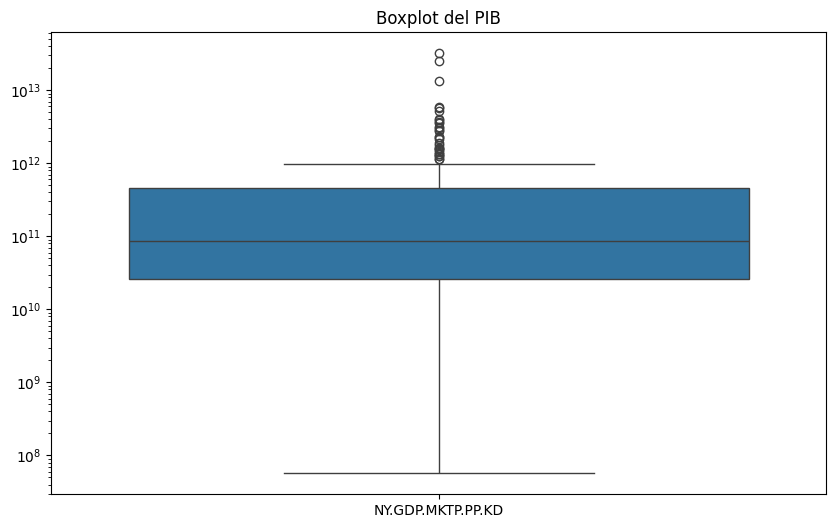

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=paises_wb[['NY.GDP.MKTP.PP.KD']])
plt.yscale('log')
plt.title("Boxplot del PIB")
plt.show()

Utilizamos un boxplot para detectar países con valores extremos de PIB que podrían afectar las visualizaciones y análisis posteriores.

Se utilizó un diagrama de caja para analizar la distribución del Producto Interno Bruto (PIB) entre los distintos países. El gráfico evidencia una marcada desigualdad en la distribución, con la presencia de varios valores extremos ubicados por sobre el límite superior de la caja. Esto indica que existen países con niveles de PIB significativamente más altos que el resto, lo cual es consistente con economías de gran tamaño como Estados Unidos, China o Alemania.

Asimismo, al emplear una escala logarítmica se logra una mejor visualización de la variabilidad total de los datos, ya que bajo una escala lineal gran parte de la información se concentraba en los valores más bajos. Este enfoque facilita la identificación de observaciones extremas que podrían distorsionar análisis posteriores, como el Análisis de Componentes Principales (PCA) o técnicas de clasificación, por lo que resulta fundamental considerar su tratamiento o evaluar su impacto en los resultados.

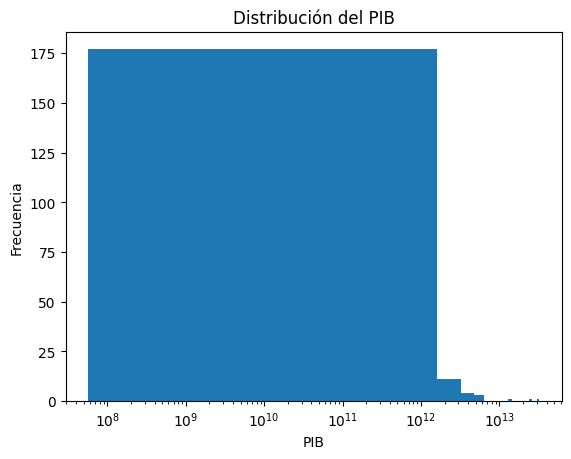

In [19]:
plt.hist(paises_wb['NY.GDP.MKTP.PP.KD'], bins=20)
plt.xscale('log')
plt.title("Distribución del PIB")
plt.xlabel("PIB")
plt.ylabel("Frecuencia")
plt.show()

Visualización distribución del PIB:
Con el histograma podemos visualizar cómo se distribuyen los valores del PIB entre los países, identificando posibles sesgos o agrupamientos.

El diagrama muestra la distribución del Producto Interno Bruto (PIB) entre los distintos países, utilizando una escala logarítmica en el eje horizontal. Esta elección se debe a que los niveles de PIB varían considerablemente entre naciones: mientras algunas presentan valores muy bajos, otras registran cifras extremadamente altas, lo que puede distorsionar la interpretación visual cuando se emplea una escala lineal.

El uso de la escala logarítmica permite:

Atenuar la asimetría de la distribución, facilitando la comparación de las diferencias entre países.

Observar que la mayoría de las naciones posee un PIB relativamente bajo, concentrándose en el extremo izquierdo del gráfico.

Identificar un grupo reducido de países con niveles de PIB muy elevados, ubicados hacia el extremo derecho, aunque sin destacar excesivamente debido a que no se realizaron ajustes adicionales en los ejes ni transformaciones extra, dado que no fueron solicitadas por el docente.

Este tipo de representación gráfica resulta útil para comprender cómo se distribuye la riqueza a nivel internacional y para evaluar el grado de concentración económica entre los países.

In [20]:
fig = px.choropleth(paises_wb,
                    locations = "country",
                    color = "NY.GDP.MKTP.PP.KD",
                    hover_name = "Country",
                    color_continuous_scale = px.colors.sequential.Plasma,
                    title = "Mapa del PIB por país")
fig.show()

Mapa de PIB por país:
Creamos un mapa interactivo donde el color representa el nivel de PIB de cada país. Esto nos permite visualizar diferencias regionales de manera intuitiva.

Análisis: Este mapa interactivo muestra la cantidad del producto interno bruto por nación usando una gama de colores. Se aplicó una progresión de color constante (Plasma) con el siguiente esquema:

- Las tonalidades profundas (azules o moradas) señalan a las naciones con un PIB menor.

- Las tonalidades vivas (anaranjadas o amarillas) señalan a los países con un PIB elevado.

- Naciones como China, Estados Unidos e India sobresalen con los tonos más intensos, señalando que poseen los productos internos brutos más grandes globalmente.

- Una gran extensión de África, la región de América Latina y ciertas zonas de Asia aparecen en matices oscuros, reflejando montos de PIB más reducidos.

Es evidente una disparidad económica a nivel mundial, ya que la prosperidad se concentra en un número reducido de estados.

Para qué sirve este diagrama:

Esta forma de mostrar información es bastante práctica para:

Contrastar el PIB entre distintos países de manera gráfica y sencilla.

Identificar tendencias espaciales o zonales en cómo se reparte el PIB.

Ayudar en la toma de decisiones o en estudios posteriores sobre economía, avance o disparidad.

In [21]:
paises_wb['GDP_Group'] = pd.qcut(paises_wb['NY.GDP.MKTP.PP.KD'], q=5,
                                 labels=['Low', 'Medium-Low', 'Medium', 'Medium-High', 'High'])

Clasificación de países según PIB (quintiles): Se agrupan los países en cinco niveles de PIB (quintiles), lo que permite hacer comparaciones entre grupos socioeconómicos similares, facilitando el análisis multivariable.

## Etapa 2

In [22]:
df_variables = paises_wb.drop(columns = ['country','Country', 'GDP_Group'])

Eliminamos las columnas no numéricas: 'country', 'Country' y 'GDP_Group', ya que el PCA solo puede aplicarse sobre variables cuantitativas.

In [23]:
df_variables = df_variables.dropna()



 También eliminamos todas las filas que contenían valores nulos (NaN) para evitar errores durante el cálculo de PCA.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_variables)

Luego aplicamos el escalado estandarizado (StandardScaler) para poder centrar las variables en media 0 y desviación estándar 1. Lo que es fundamental, porque el PCA es sensible a las escalas.

In [25]:
from sklearn.decomposition import PCA

pca = PCA()
X_pca = pca.fit_transform(X_scaled)
varianza_acumulada = np.cumsum(pca.explained_variance_ratio_)

Aplicamos PCA sobre los datos estandarizados y se calcula la varianza explicada acumulada.

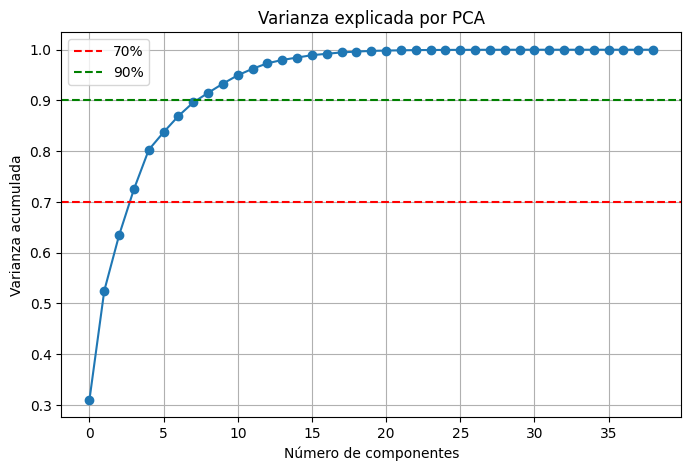

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(varianza_acumulada, marker='o')
plt.axhline(y=0.7, color='r', linestyle='--', label = '70%')
plt.axhline(y=0.9, color='g', linestyle='--', label = '90%')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada por PCA')
plt.legend()
plt.grid()
plt.show()

Aquí graficamos la varianza acumulada explicada por cada componente principal. Además, se agregaron líneas horizontales que marcan los umbrales del 70% y 90% de varianza.

## Al aplicar el PCA y graficat la variación total, notamos esto:

- Con solo las primeras 3 componentes, ya cubríamos arriba del 70% de la variación.

- Desde la componente número 4, el progreso en la variación explicada se vuelve más pausado.

Necesitamos 9 componentes para llegar a cubrir el 90% de la variación total.

Esto sugiere que las primeras pocas componentes agrupan la gran mayoría de la información de la muestra, lo cual es usual en datos que tienen mucha relación o repetición entre sí.

## Análisis del gráfico:

El gráfico presenta la varianza acumulada explicada por cada componente principal obtenida mediante el Análisis de Componentes Principales (PCA).

Los primeros tres o cuatro componentes concentran una proporción significativa de la varianza total, superando el 70 % (línea roja discontinua).

Al considerar nueve componentes, se alcanza aproximadamente el 90 % de la varianza total explicada (línea verde discontinua).

A partir del décimo componente en adelante, los incrementos en la varianza explicada son marginales, lo que indica rendimientos decrecientes al incorporar componentes adicionales.

En consecuencia, la gráfica muestra que los primeros componentes capturan prácticamente toda la información relevante del conjunto de datos. Por ello, seleccionar los primeros nueve componentes constituye una decisión adecuada, ya que permite mantener un balance entre simplicidad del modelo y precisión en la representación de la información.

In [27]:

varianza_acumulada = pca.explained_variance_ratio_.cumsum()

n_componentes = np.argmax(varianza_acumulada >= 0.90) + 1
print(f"Componentes necesarios para explicar al menos el 90% de la varianza: {n_componentes}")

Componentes necesarios para explicar al menos el 90% de la varianza: 9


Se seleccionó automáticamente el número mínimo de componentes que explican al menos el 90% de la varianza. En este caso, el número fue el 9

Decidimos escoger 9 elementos clave, dado que esa cantidad es la menor requerida para cubrir un mínimo del 90% de la dispersión global, tal como se aprecia en el diagrama de varianza sumada.

La eleccion de este umbral es porque:

- Garantiza que se conserve la mayor parte de los datos iniciales del conjunto (mucha fidelidad).

- Baja considerablemente el número de dimensiones (de varias características iniciales a solo 9), lo que optimiza el cálculo y previene el exceso de ajuste en los modelos que sigan.

Si bien el 70% ya cubría bastante dispersión, se prefirió el 90% con el fin de hallar un punto medio entre hacer más simple y guardar datos.

In [34]:
pca_final = PCA(n_components=n_componentes)
X_pca_final = pca_final.fit_transform(X_scaled)

columnas_pca = [f"PC{i+1}" for i in range(n_componentes)]
df_paises_pca = pd.DataFrame(X_pca_final, columns=columnas_pca)

df_paises_pca['country'] = paises_wb['country']
df_paises_pca['Country'] = paises_wb['Country']

df_paises_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,country,Country
0,-1.965927,-4.339676,-0.281187,0.352990,-0.345371,1.023814,-0.688314,0.056145,0.123955,ZWE,Zimbabwe
1,1.084663,0.082034,0.444250,-0.256022,-2.156366,-0.622007,-0.676289,-1.614453,1.411961,ZMB,Zambia
2,-0.484669,-0.540100,0.192079,0.933217,-0.349670,-0.849362,0.653750,0.004440,0.324616,PSE,West Bank and Gaza
3,-0.023130,3.096453,-0.416295,-1.413028,0.247126,0.394376,-0.120259,0.860581,-1.203504,VNM,Viet Nam
4,2.270925,2.361702,-0.694883,0.562225,-0.770882,1.142028,0.273085,0.242822,-0.612954,VUT,Vanuatu


Aquí se construyó un nuevo DataFrame que contiene las nueve componentes principales seleccionadas, al cual se incorporaron nuevamente las columnas correspondientes al nombre del país.

In [72]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score, classification_report, confusion_matrix

Definimos variables a utilizar

In [61]:
# Variables originales
x = df_variables
y = paises_wb.loc[df_variables.index, 'GDP_Group']

Asigmanos las variables

In [63]:
X_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42, stratify=y)

In [66]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(x_test)

In [68]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(x_test)

In [69]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

In [70]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

===== MODELO KNN (SIN PCA) ====
Accuracy: 0.5
Balanced Accuracy: 0.49111111111111116

Reporte de clasificación:

              precision    recall  f1-score   support

        High       0.75      0.90      0.82        10
         Low       0.67      0.67      0.67         3
      Medium       0.35      0.67      0.46         9
 Medium-High       0.33      0.22      0.27         9
  Medium-Low       0.00      0.00      0.00         7

    accuracy                           0.50        38
   macro avg       0.42      0.49      0.44        38
weighted avg       0.41      0.50      0.44        38



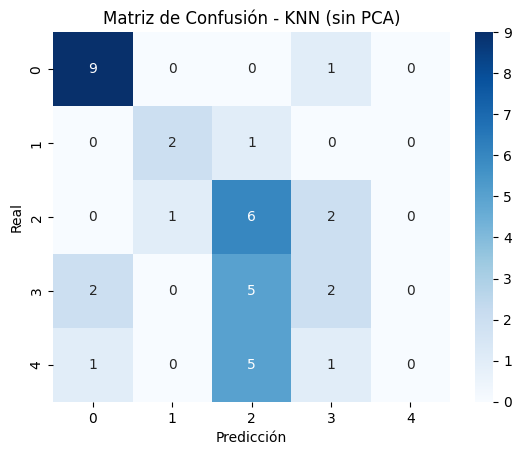

In [75]:
print("===== MODELO KNN (SIN PCA) ====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_knn, zero_division=0))

cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - KNN (sin PCA)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

===== MODELO RANDOM FOREST (SIN PCA) ====
Accuracy: 0.9210526315789473
Balanced Accuracy: 0.9355555555555555

Reporte de clasificación:

              precision    recall  f1-score   support

        High       1.00      0.90      0.95        10
         Low       1.00      1.00      1.00         3
      Medium       1.00      0.78      0.88         9
 Medium-High       0.90      1.00      0.95         9
  Medium-Low       0.78      1.00      0.88         7

    accuracy                           0.92        38
   macro avg       0.94      0.94      0.93        38
weighted avg       0.94      0.92      0.92        38



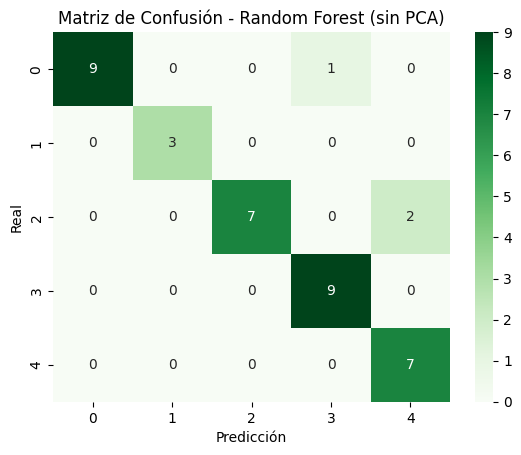

In [76]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate and train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test_scaled)

print("===== MODELO RANDOM FOREST (SIN PCA) ====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf, zero_division=0))

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest (sin PCA)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [78]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada acumulada: 0.8965355041906842


In [79]:
from sklearn.decomposition import PCA

pca = PCA(n_components=9, random_state=42)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Varianza explicada acumulada:", pca.explained_variance_ratio_.sum())

Varianza explicada acumulada: 0.8965355041906842


In [82]:
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_pca.fit(X_train_pca, y_train)

y_pred_knn_pca = knn_pca.predict(X_test_pca)

In [84]:
rf_pca = RandomForestClassifier(n_estimators=100, random_state=42)
rf_pca.fit(X_train_pca, y_train)

y_pred_rf_pca = rf_pca.predict(X_test_pca)

In [85]:
print("===== MODELO KNN (CON PCA) ====")
print("Accuracy:", accuracy_score(y_test, y_pred_knn_pca))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_knn_pca))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_knn_pca, zero_division=0))

===== MODELO KNN (CON PCA) ====
Accuracy: 0.5263157894736842
Balanced Accuracy: 0.5133333333333334

Reporte de clasificación:

              precision    recall  f1-score   support

        High       1.00      0.90      0.95        10
         Low       1.00      0.67      0.80         3
      Medium       0.35      0.67      0.46         9
 Medium-High       0.38      0.33      0.35         9
  Medium-Low       0.00      0.00      0.00         7

    accuracy                           0.53        38
   macro avg       0.55      0.51      0.51        38
weighted avg       0.51      0.53      0.51        38



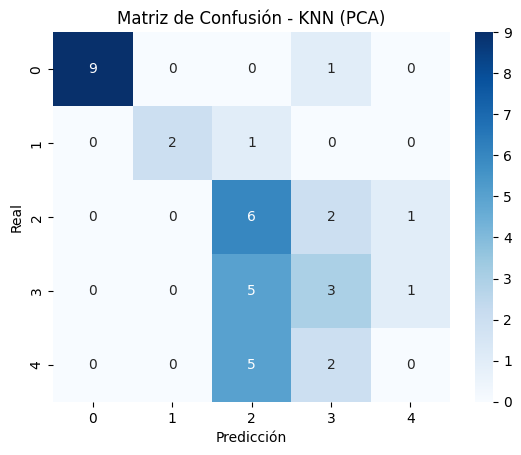

In [86]:
cm_knn_pca = confusion_matrix(y_test, y_pred_knn_pca)
sns.heatmap(cm_knn_pca, annot=True, fmt='d', cmap='Blues')
plt.title("Matriz de Confusión - KNN (PCA)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

===== MODELO RANDOM FOREST (CON PCA) ====
Accuracy: 0.5789473684210527
Balanced Accuracy: 0.5174603174603175

Reporte de clasificación:

              precision    recall  f1-score   support

        High       0.83      1.00      0.91        10
         Low       0.20      0.33      0.25         3
      Medium       0.46      0.67      0.55         9
 Medium-High       0.57      0.44      0.50         9
  Medium-Low       1.00      0.14      0.25         7

    accuracy                           0.58        38
   macro avg       0.61      0.52      0.49        38
weighted avg       0.66      0.58      0.55        38



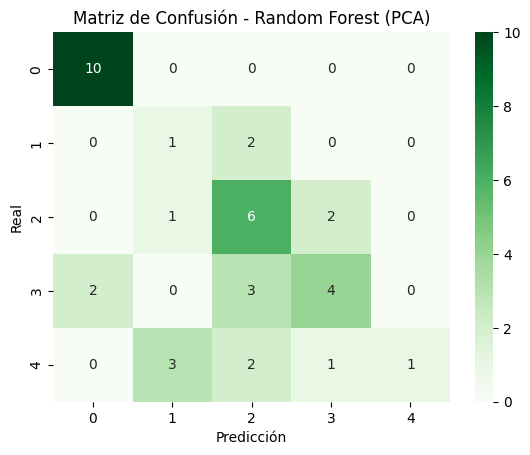

In [87]:
print("===== MODELO RANDOM FOREST (CON PCA) ====")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_pca))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_rf_pca))
print("\nReporte de clasificación:\n")
print(classification_report(y_test, y_pred_rf_pca, zero_division=0))

cm_rf_pca = confusion_matrix(y_test, y_pred_rf_pca)
sns.heatmap(cm_rf_pca, annot=True, fmt='d', cmap='Greens')
plt.title("Matriz de Confusión - Random Forest (PCA)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

In [88]:
from sklearn.metrics import f1_score
import pandas as pd

comparacion = pd.DataFrame({
"Modelo": [
"KNN (sin PCA)",
"Random Forest (sin PCA)",
"KNN (con PCA)",
"Random Forest (con PCA)"
],
"Accuracy": [
accuracy_score(y_test, y_pred_knn),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_knn_pca),
accuracy_score(y_test, y_pred_rf_pca)
],
"Balanced Accuracy": [
balanced_accuracy_score(y_test, y_pred_knn),
balanced_accuracy_score(y_test, y_pred_rf),
balanced_accuracy_score(y_test, y_pred_knn_pca),
balanced_accuracy_score(y_test, y_pred_rf_pca)
],
"F1 weighted": [
f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
f1_score(y_test, y_pred_rf, average="weighted", zero_division=0),
f1_score(y_test, y_pred_knn_pca, average="weighted", zero_division=0),
f1_score(y_test, y_pred_rf_pca, average="weighted", zero_division=0)
]
})

comparacion.sort_values(by="F1 weighted", ascending=False)


,Modelo,Accuracy,Balanced Accuracy,F1 weighted
1,Random Forest (sin PCA),0.921053,0.935556,0.921053
3,Random Forest (con PCA),0.578947,0.517460,0.552632
2,KNN (con PCA),0.526316,0.513333,0.505368
0,KNN (sin PCA),0.500000,0.491111,0.440412


In [89]:
from sklearn.metrics import f1_score
import pandas as pd

comparacion = pd.DataFrame({
"Modelo": [
"KNN (sin PCA)",
"Random Forest (sin PCA)",
"KNN (con PCA)",
"Random Forest (con PCA)"
],
"Accuracy": [
accuracy_score(y_test, y_pred_knn),
accuracy_score(y_test, y_pred_rf),
accuracy_score(y_test, y_pred_knn_pca),
accuracy_score(y_test, y_pred_rf_pca)
],
"Balanced Accuracy": [
balanced_accuracy_score(y_test, y_pred_knn),
balanced_accuracy_score(y_test, y_pred_rf),
balanced_accuracy_score(y_test, y_pred_knn_pca),
balanced_accuracy_score(y_test, y_pred_rf_pca)
],
"F1 weighted": [
f1_score(y_test, y_pred_knn, average="weighted", zero_division=0),
f1_score(y_test, y_pred_rf, average="weighted", zero_division=0),
f1_score(y_test, y_pred_knn_pca, average="weighted", zero_division=0),
f1_score(y_test, y_pred_rf_pca, average="weighted", zero_division=0)
]
})

comparacion.sort_values(by="F1 weighted", ascending=False)


,Modelo,Accuracy,Balanced Accuracy,F1 weighted
1,Random Forest (sin PCA),0.921053,0.935556,0.921053
3,Random Forest (con PCA),0.578947,0.517460,0.552632
2,KNN (con PCA),0.526316,0.513333,0.505368
0,KNN (sin PCA),0.500000,0.491111,0.440412
